<a href="https://colab.research.google.com/github/yeyevtushenko/NLP_YevtushenkoBS-25/blob/main/NLP_%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%BD%D0%B0_%D1%80%D0%BE%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%965_%D0%84%D0%B2%D1%82%D1%83%D1%88%D0%B5%D0%BD%D0%BA%D0%BE_%D0%91%D0%A1_25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Практична робота №5

In [1]:
!pip install pyconll

In [21]:
import os
import requests
import pyconll
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
import torch
import pandas as pd

from collections import Counter
from torch.utils.data import TensorDataset, DataLoader, Subset

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


##1. Реалізація базового коду. Реалізуйте базову модель POS-тегування, наведену у практикумі. Завантажте дані корпусу Universal Dependencies (UD) та підготуйте їх для моделі. Запустіть навчання моделі на обмеженому датасеті (перші 1000 речень). Збережіть найкращу модель.

ukrainian_pos_train.conllu вже завантажено.
ukrainian_pos_dev.conllu вже завантажено.
ukrainian_pos_test.conllu вже завантажено.
Train: 5521 речень
Dev: 673 речень
Test: 898 речень

Речення 1:
У	ADP
домі	NOUN
римського	ADJ
патриція	NOUN
Руфіна	PROPN
була	VERB
прегарна	ADJ
фреска	NOUN
,	PUNCT
зображення	NOUN
Венери	PROPN
та	CCONJ
Адоніса	PROPN
.	PUNCT

Речення 2:
Якось	ADV
зібралися	VERB
у	ADP
нього	PRON
,	PUNCT
ховаючися	VERB
від	ADP
переслідувань	NOUN
,	PUNCT
одновірці	NOUN
дружини	NOUN
–	PUNCT
християнки	NOUN
.	PUNCT

Максимальна довжина речення: 197
Максимальна довжина токена: 115

Розмір словника символів: 190
Перші 10 символів у словнику:
Символ: '<PAD>' -> Номер: 0
Символ: ' ' -> Номер: 1
Символ: '!' -> Номер: 2
Символ: '"' -> Номер: 3
Символ: '#' -> Номер: 4
Символ: '$' -> Номер: 5
Символ: '%' -> Номер: 6
Символ: '&' -> Номер: 7
Символ: ''' -> Номер: 8
Символ: '(' -> Номер: 9

Найчастотніші символи:
Символ: 'о' -> Частота: 38005
Символ: 'а' -> Частота: 33855
Символ: 'н' -> Часто

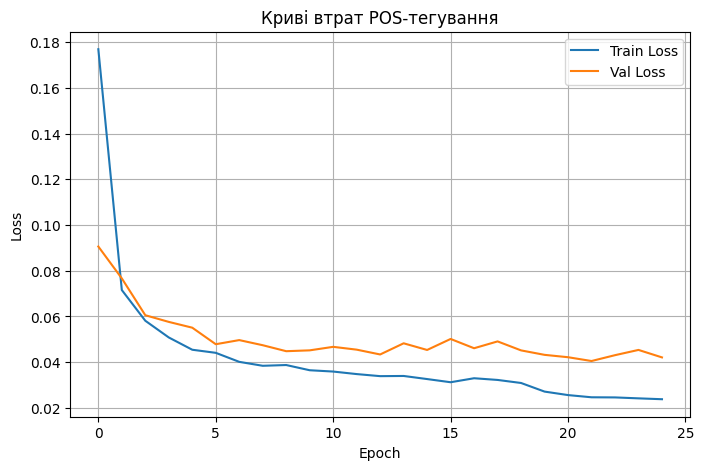

In [15]:
DATASETS = {
    "train": "https://raw.githubusercontent.com/UniversalDependencies/UD_Ukrainian-IU/master/uk_iu-ud-train.conllu",
    "dev": "https://raw.githubusercontent.com/UniversalDependencies/UD_Ukrainian-IU/master/uk_iu-ud-dev.conllu",
    "test": "https://raw.githubusercontent.com/UniversalDependencies/UD_Ukrainian-IU/master/uk_iu-ud-test.conllu"
}

def save_model(model, filepath):
    torch.save(model.state_dict(), filepath)
    print(f"Модель збережено в {filepath}")

def load_model(model, filepath, device="cpu"):
    model.load_state_dict(torch.load(filepath, map_location=device))
    model.to(device)
    print(f"Модель завантажено з {filepath}")

def download_corpus(url, save_path):
    if not os.path.exists(save_path):
        print(f"Завантаження {save_path}...")
        response = requests.get(url)
        with open(save_path, "w", encoding="utf-8") as f:
            f.write(response.text)
        print(f"{save_path} завантажено.")
    else:
        print(f"{save_path} вже завантажено.")
    return save_path

corpora_paths = {}
for split, url in DATASETS.items():
    save_path = f"ukrainian_pos_{split}.conllu"
    corpora_paths[split] = download_corpus(url, save_path)

train_data = pyconll.load_from_file(corpora_paths["train"])
dev_data = pyconll.load_from_file(corpora_paths["dev"])
test_data = pyconll.load_from_file(corpora_paths["test"])

print(f"Train: {len(train_data)} речень")
print(f"Dev: {len(dev_data)} речень")
print(f"Test: {len(test_data)} речень")

for i, sentence in enumerate(train_data[:2]):
    print(f"\nРечення {i+1}:")
    for token in sentence:
        print(f"{token.form}\t{token.upos}")

max_sentence_length = max(len(sentence) for sentence in train_data)
max_token_length = max(len(token.form) for sentence in train_data for token in sentence)

print(f"\nМаксимальна довжина речення: {max_sentence_length}")
print(f"Максимальна довжина токена: {max_token_length}")

def build_char_vocab(data):
    char_counter = Counter()
    for sentence in data:
        for token in sentence:
            char_counter.update(token.form)

    char_vocab = {
        "<PAD>": 0,
        **{char: idx + 1 for idx, char in enumerate(sorted(char_counter.keys()))}
    }
    return char_vocab

char_vocab = build_char_vocab(train_data)
print(f"\nРозмір словника символів: {len(char_vocab)}")

print("Перші 10 символів у словнику:")
for char, idx in list(char_vocab.items())[:10]:
    print(f"Символ: '{char}' -> Номер: {idx}")

char_counter = Counter()
for sentence in train_data:
    for token in sentence:
        char_counter.update(token.form)

print("\nНайчастотніші символи:")
for char, count in char_counter.most_common(10):
    print(f"Символ: '{char}' -> Частота: {count}")

def build_pos_vocab(data):
    pos_tags = sorted({
        token.upos
        for sentence in data
        for token in sentence
        if token.upos is not None
    })
    pos_vocab = {pos: idx + 1 for idx, pos in enumerate(pos_tags)}
    pos_vocab["<PAD>"] = 0
    return pos_vocab

pos_vocab = build_pos_vocab(train_data)
print(f"\nРозмір словника частин мови: {len(pos_vocab)}")

assert None not in pos_vocab

def get_pos_examples(data, pos_vocab, num_examples=3):
    pos_examples = {pos: [] for pos in pos_vocab.keys() if pos != "<PAD>"}

    for sentence in data:
        for token in sentence:
            pos = token.upos
            if pos in pos_examples and len(pos_examples[pos]) < num_examples:
                pos_examples[pos].append(token.form)

    return pos_examples

pos_examples = get_pos_examples(train_data, pos_vocab)

print("\nПриклади для кожного POS-тегу:")
for pos, examples in pos_examples.items():
    print(f"{pos}: {', '.join(examples)}")

def convert_to_tensors(data, char_vocab, pos_vocab, max_token_len, max_sent_len):
    num_sentences = len(data)

    char_tensor = torch.zeros((num_sentences, max_sent_len, max_token_len), dtype=torch.long)
    pos_tensor = torch.zeros((num_sentences, max_sent_len), dtype=torch.long)

    for i, sentence in enumerate(data):
        for j, token in enumerate(sentence):
            if j >= max_sent_len:
                break

            token_chars = [char_vocab.get(char, 0) for char in token.form[:max_token_len]]
            char_tensor[i, j, :len(token_chars)] = torch.tensor(token_chars, dtype=torch.long)

            pos_tensor[i, j] = pos_vocab.get(token.upos, 0)

    return char_tensor, pos_tensor

max_token_len = max(len(token.form) for sentence in train_data for token in sentence)
max_sent_len = max(len(sentence) for sentence in train_data)

train_char_tensor, train_pos_tensor = convert_to_tensors(
    train_data, char_vocab, pos_vocab, max_token_len, max_sent_len
)
dev_char_tensor, dev_pos_tensor = convert_to_tensors(
    dev_data, char_vocab, pos_vocab, max_token_len, max_sent_len
)
test_char_tensor, test_pos_tensor = convert_to_tensors(
    test_data, char_vocab, pos_vocab, max_token_len, max_sent_len
)

print(f"\nФорма тензора символів: {train_char_tensor.shape}")
print(f"Форма тензора POS-тегів: {train_pos_tensor.shape}")

def add_special_columns(char_tensor):
    batch_size, max_sent_len, max_token_len = char_tensor.shape
    special_tensor = torch.zeros((batch_size, max_sent_len, max_token_len + 2), dtype=torch.long)
    special_tensor[:, :, 1:-1] = char_tensor
    return special_tensor

train_char_tensor = add_special_columns(train_char_tensor)
dev_char_tensor = add_special_columns(dev_char_tensor)
test_char_tensor = add_special_columns(test_char_tensor)

print(f"Оновлена форма тензора символів: {train_char_tensor.shape}")
print(train_char_tensor[1][:5])
print(train_pos_tensor[1])

class ConvBlock(nn.Module):
    def __init__(self, in_channels, kernel_size=3, dropout=0.1):
        super(ConvBlock, self).__init__()
        self.conv = nn.Conv1d(
            in_channels=in_channels,
            out_channels=in_channels,
            kernel_size=kernel_size,
            padding=kernel_size // 2
        )
        self.dropout = nn.Dropout(dropout)
        self.activation = nn.LeakyReLU(negative_slope=0.1)

    def forward(self, x):
        out = self.conv(x)
        out = self.dropout(out)
        out = self.activation(out)
        return out

class ConvResNet(nn.Module):
    def __init__(self, in_channels, num_layers, kernel_size=3, dropout=0.1):
        super(ConvResNet, self).__init__()
        self.layers = nn.ModuleList([
            ConvBlock(in_channels, kernel_size, dropout)
            for _ in range(num_layers)
        ])

    def forward(self, x):
        for layer in self.layers:
            out = layer(x)
            x = x + out
        return x

class TokenEmbedding(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super(TokenEmbedding, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)

    def forward(self, x):
        batch_size, max_sentence_len, max_token_len = x.size()

        x = x.view(-1, max_token_len)
        x = self.embedding(x)
        x = x.permute(0, 2, 1)

        return x

class TokenPOSTagger(nn.Module):
    def __init__(
        self,
        vocab_size,
        labels_num,
        embedding_size=32,
        num_res_layers=3,
        kernel_size=3,
        dropout=0.1
    ):
        super().__init__()

        self.token_embedding = TokenEmbedding(vocab_size, embedding_size)

        self.backbone = ConvResNet(
            in_channels=embedding_size,
            num_layers=num_res_layers,
            kernel_size=kernel_size,
            dropout=dropout
        )

        self.global_pooling = nn.AdaptiveMaxPool1d(1)
        self.out = nn.Linear(embedding_size, labels_num)

    def forward(self, tokens):
        batch_size, max_sentence_len, max_token_len = tokens.shape

        char_embeddings = self.token_embedding(tokens)
        features = self.backbone(char_embeddings)
        global_features = self.global_pooling(features).squeeze(-1)
        logits_flat = self.out(global_features)

        logits = logits_flat.view(batch_size, max_sentence_len, -1)
        return logits

def train_eval_loop(
    model,
    train_loader,
    val_loader,
    num_epochs=25,
    lr=5e-3,
    lr_decay=0.5,
    patience=5,
    loss_fn=nn.CrossEntropyLoss(),
    optimizer_ctor=torch.optim.Adam,
    device="cpu",
    save_path="best_model_4_1_1.pth"
):
    optimizer = optimizer_ctor(model.parameters(), lr=lr)
    lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        patience=patience,
        factor=lr_decay
    )

    train_losses, val_losses = [], []
    best_val_loss = float("inf")

    for epoch in range(1, num_epochs + 1):
        model.train()
        total_train_loss = 0.0

        for batch in train_loader:
            sentences, labels = batch
            sentences, labels = sentences.to(device), labels.to(device)

            optimizer.zero_grad()
            logits = model(sentences)
            loss = loss_fn(logits.view(-1, logits.size(-1)), labels.view(-1))
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

        train_loss = total_train_loss / len(train_loader)
        train_losses.append(train_loss)

        model.eval()
        total_val_loss = 0.0

        with torch.no_grad():
            for batch in val_loader:
                sentences, labels = batch
                sentences, labels = sentences.to(device), labels.to(device)

                logits = model(sentences)
                loss = loss_fn(logits.view(-1, logits.size(-1)), labels.view(-1))
                total_val_loss += loss.item()

        val_loss = total_val_loss / len(val_loader)
        val_losses.append(val_loss)

        print(f"Epoch {epoch}/{num_epochs} — Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            save_model(model, save_path)

        lr_scheduler.step(val_loss)

    return train_losses, val_losses

vocab_size = len(char_vocab)
labels_num = len(pos_vocab)

embedding_size = 64
num_res_layers = 3
kernel_size = 3
dropout = 0.3

model = TokenPOSTagger(
    vocab_size=vocab_size,
    labels_num=labels_num,
    embedding_size=embedding_size,
    num_res_layers=num_res_layers,
    kernel_size=kernel_size,
    dropout=dropout
)

model.to(device)

train_dataset = TensorDataset(train_char_tensor, train_pos_tensor)
val_dataset = TensorDataset(test_char_tensor, test_pos_tensor)

batch_size = 8
subset_size = 1000

train_subset = Subset(train_dataset, range(subset_size))
val_subset = Subset(val_dataset, range(subset_size // 2))

train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)

train_losses, val_losses = train_eval_loop(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=25,
    lr=5e-3,
    lr_decay=0.5,
    patience=5,
    loss_fn=torch.nn.CrossEntropyLoss(),
    optimizer_ctor=torch.optim.Adam,
    device=device,
    save_path="best_model_4_1_1.pth"
)

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Криві втрат POS-тегування")
plt.legend()
plt.grid(True)
plt.show()

###Чи вдалося знизити втрати на тренувальних і валідаційних даних?

Навчання проводилось на обмеженому наборі з перших 1000 речень, а найкраща модель автоматично зберігалась у файл best_model_4_1_1.pth. У процесі навчання втрати на тренувальних і валідаційних даних суттєво зменшилися: train loss знизився з 0.1770 до 0.0238, а val loss — з 0.0906 до 0.0421. Це свідчить про успішне навчання моделі.

##Додайте підрахунок метрик. Використовуйте функцію evaluate_model, щоб оцінити якість роботи моделі. Порівняйте точність, повноту та F1-міру для різних POS-тегів.

In [17]:
def evaluate_model(model, data_loader, label_vocab, device="cpu"):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in data_loader:
            sentences, labels = batch
            sentences, labels = sentences.to(device), labels.to(device)

            logits = model(sentences)
            preds = torch.argmax(logits, dim=-1)

            all_preds.extend(preds.cpu().numpy().reshape(-1))
            all_labels.extend(labels.cpu().numpy().reshape(-1))

    # індекси → теги
    id_to_label = {idx: label for label, idx in label_vocab.items()}

    filtered_preds = []
    filtered_labels = []

    for pred, label in zip(all_preds, all_labels):
        if label != 0:  # ігноруємо <PAD>
            filtered_labels.append(id_to_label.get(label, "<UNK>"))
            filtered_preds.append(id_to_label.get(pred, "<UNK>"))

    print(classification_report(filtered_labels, filtered_preds))

In [18]:
print("=== TRAIN METRICS ===")
evaluate_model(model, train_loader, pos_vocab, device)

print("\n=== VALIDATION METRICS ===")
evaluate_model(model, val_loader, pos_vocab, device)

=== TRAIN METRICS ===
              precision    recall  f1-score   support

         ADJ       0.93      0.94      0.93      1490
         ADP       0.99      0.99      0.99      1391
         ADV       0.93      0.85      0.89      1123
         AUX       0.74      1.00      0.85       192
       CCONJ       0.88      0.90      0.89       741
         DET       0.91      0.85      0.88       720
        INTJ       0.96      0.88      0.92        25
        NOUN       0.96      0.95      0.95      3525
         NUM       0.90      0.85      0.88        62
        PART       0.86      0.84      0.85       750
        PRON       0.87      0.92      0.89       873
       PROPN       0.97      0.94      0.95       414
       PUNCT       1.00      1.00      1.00      3331
       SCONJ       0.82      0.96      0.89       408
         SYM       1.00      0.80      0.89        10
        VERB       0.97      0.96      0.96      2093
           X       1.00      0.91      0.95        53

    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


###Для яких тегів модель дає найкращі результати? Для яких тегів результати найгірші? Чи є значна різниця між результатами на тренувальних і валідаційних наборах?

Аналіз показав, що модель демонструє найкращі результати для тегів PUNCT, ADP, VERB та NOUN (F1 ≈ 0.9–1.0), що пояснюється їх чіткою структурою та високою частотою в корпусі.

Найгірші результати спостерігаються для тегів SYM, PROPN, NUM та ADV, де F1-міра значно нижча, особливо на валідаційному наборі. Це пов’язано з малою кількістю прикладів, багатозначністю слів та відсутністю врахування контексту в моделі.

##Експерименти з гіперпараметрами. Змініть такі параметри, як розмір ембеддінгів, кількість шарів ResNet, розмір ядра (kernel_size), швидкість навчання (learning rate), та кількість епох. Знайдіть конфігурацію, яка забезпечує найкращі результати.

In [19]:
def run_experiment(
    embedding_size=64,
    num_res_layers=3,
    kernel_size=3,
    dropout=0.3,
    lr=5e-3,
    num_epochs=15,
    save_path="temp_model.pth"
):
    model = TokenPOSTagger(
        vocab_size=len(char_vocab),
        labels_num=len(pos_vocab),
        embedding_size=embedding_size,
        num_res_layers=num_res_layers,
        kernel_size=kernel_size,
        dropout=dropout
    ).to(device)

    train_losses, val_losses = train_eval_loop(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        num_epochs=num_epochs,
        lr=lr,
        lr_decay=0.5,
        patience=5,
        loss_fn=torch.nn.CrossEntropyLoss(),
        optimizer_ctor=torch.optim.Adam,
        device=device,
        save_path=save_path
    )

    best_val = min(val_losses)

    return {
        "embedding_size": embedding_size,
        "num_res_layers": num_res_layers,
        "kernel_size": kernel_size,
        "lr": lr,
        "num_epochs": num_epochs,
        "best_train_loss": min(train_losses),
        "best_val_loss": best_val
    }

In [20]:
results = []

configs = [
    {"embedding_size": 32,  "num_res_layers": 2, "kernel_size": 3, "lr": 5e-3, "num_epochs": 15},
    {"embedding_size": 64,  "num_res_layers": 3, "kernel_size": 3, "lr": 5e-3, "num_epochs": 15},
    {"embedding_size": 128, "num_res_layers": 3, "kernel_size": 3, "lr": 5e-3, "num_epochs": 15},
    {"embedding_size": 64,  "num_res_layers": 4, "kernel_size": 3, "lr": 5e-3, "num_epochs": 15},
    {"embedding_size": 64,  "num_res_layers": 3, "kernel_size": 5, "lr": 5e-3, "num_epochs": 15},
    {"embedding_size": 64,  "num_res_layers": 3, "kernel_size": 3, "lr": 1e-3, "num_epochs": 20},
]

for i, cfg in enumerate(configs, 1):
    print(f"\n===== Експеримент {i} / {len(configs)} =====")
    result = run_experiment(
        embedding_size=cfg["embedding_size"],
        num_res_layers=cfg["num_res_layers"],
        kernel_size=cfg["kernel_size"],
        lr=cfg["lr"],
        num_epochs=cfg["num_epochs"],
        save_path=f"best_model_exp_{i}.pth"
    )
    results.append(result)


===== Експеримент 1 / 6 =====
Epoch 1/15 — Train Loss: 0.2848, Val Loss: 0.1555
Модель збережено в best_model_exp_1.pth
Epoch 2/15 — Train Loss: 0.1069, Val Loss: 0.1233
Модель збережено в best_model_exp_1.pth
Epoch 3/15 — Train Loss: 0.0877, Val Loss: 0.1029
Модель збережено в best_model_exp_1.pth
Epoch 4/15 — Train Loss: 0.0766, Val Loss: 0.0885
Модель збережено в best_model_exp_1.pth
Epoch 5/15 — Train Loss: 0.0710, Val Loss: 0.0845
Модель збережено в best_model_exp_1.pth
Epoch 6/15 — Train Loss: 0.0665, Val Loss: 0.0842
Модель збережено в best_model_exp_1.pth
Epoch 7/15 — Train Loss: 0.0635, Val Loss: 0.0791
Модель збережено в best_model_exp_1.pth
Epoch 8/15 — Train Loss: 0.0590, Val Loss: 0.0737
Модель збережено в best_model_exp_1.pth
Epoch 9/15 — Train Loss: 0.0555, Val Loss: 0.0710
Модель збережено в best_model_exp_1.pth
Epoch 10/15 — Train Loss: 0.0544, Val Loss: 0.0646
Модель збережено в best_model_exp_1.pth
Epoch 11/15 — Train Loss: 0.0520, Val Loss: 0.0682
Epoch 12/15 — Tra

In [22]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="best_val_loss")
print(results_df)

   embedding_size  num_res_layers  kernel_size     lr  num_epochs  \
4              64               3            5  0.005          15   
2             128               3            3  0.005          15   
3              64               4            3  0.005          15   
1              64               3            3  0.005          15   
5              64               3            3  0.001          20   
0              32               2            3  0.005          15   

   best_train_loss  best_val_loss  
4         0.027373       0.040677  
2         0.028087       0.044974  
3         0.033132       0.048168  
1         0.033025       0.048849  
5         0.035255       0.054716  
0         0.047715       0.061968  


###Яка комбінація гіперпараметрів забезпечує найкращі результати?

Було проведено серію експериментів із гіперпараметрами моделі POS-тегування, зокрема змінювалися розмір ембеддінгів, кількість ResNet-шарів, розмір ядра згортки, швидкість навчання та кількість епох. Порівняння проводилося за значенням функції втрат на валідаційному наборі. У результаті встановлено, що найкращу якість моделі забезпечує конфігурація: embedding_size = 64, num_res_layers = 3, kernel_size = 5, learning_rate = 0.005, num_epochs = 15, для якої було досягнуто мінімальне значення валідаційної втрати 0.0407 Збільшення розміру ембеддінгів з 32 до 64 покращує якість моделі, однак подальше збільшення до 128 не дає додаткового виграшу. Оптимальною кількістю згорткових шарів є 3, тоді як збільшення до 4 призводить до погіршення результатів, що може свідчити про перенавчання. Використання ядра згортки розміру 5 дозволяє краще враховувати локальні залежності між символами, ніж kernel_size = 3. Найкращою швидкістю навчання виявилася 0.005, тоді як менше значення уповільнює навчання та погіршує результати. Збільшення кількості епох понад 15 не призводить до суттєвого покращення якості моделі.

##Використовуйте classification_report для аналізу точності передбачень.

In [23]:
def evaluate_model(model, data_loader, label_vocab, device="cpu"):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in data_loader:
            sentences, labels = batch
            sentences, labels = sentences.to(device), labels.to(device)

            logits = model(sentences)
            preds = torch.argmax(logits, dim=-1)

            all_preds.extend(preds.cpu().numpy().reshape(-1))
            all_labels.extend(labels.cpu().numpy().reshape(-1))

    # індекси -> назви тегів
    id_to_label = {idx: label for label, idx in label_vocab.items()}

    filtered_preds = []
    filtered_labels = []

    for pred, label in zip(all_preds, all_labels):
        if label != 0:  # ігноруємо <PAD>
            filtered_labels.append(id_to_label.get(label, "<UNK>"))
            filtered_preds.append(id_to_label.get(pred, "<UNK>"))

    report = classification_report(filtered_labels, filtered_preds)
    print(report)

In [24]:
print("=== TRAIN METRICS ===")
evaluate_model(model, train_loader, pos_vocab, device)

print("\n=== VALIDATION METRICS ===")
evaluate_model(model, val_loader, pos_vocab, device)

=== TRAIN METRICS ===
              precision    recall  f1-score   support

         ADJ       0.93      0.94      0.93      1490
         ADP       0.99      0.99      0.99      1391
         ADV       0.93      0.85      0.89      1123
         AUX       0.74      1.00      0.85       192
       CCONJ       0.88      0.90      0.89       741
         DET       0.91      0.85      0.88       720
        INTJ       0.96      0.88      0.92        25
        NOUN       0.96      0.95      0.95      3525
         NUM       0.90      0.85      0.88        62
        PART       0.86      0.84      0.85       750
        PRON       0.87      0.92      0.89       873
       PROPN       0.97      0.94      0.95       414
       PUNCT       1.00      1.00      1.00      3331
       SCONJ       0.82      0.96      0.89       408
         SYM       1.00      0.80      0.89        10
        VERB       0.97      0.96      0.96      2093
           X       1.00      0.91      0.95        53

    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


##Контрольні питання

###1. Що таке POS-тегування? Чому ця задача важлива для обробки тексту?
POS-тегування — це задача визначення частини мови для кожного слова в реченні (наприклад, іменник, дієслово, прикметник). Вона є важливою, оскільки забезпечує структурне розуміння тексту та використовується в задачах синтаксичного аналізу, машинного перекладу та інформаційного пошуку.
###2. Які кроки необхідно виконати для підготовки корпусу до навчання моделі?
Підготовка корпусу включає завантаження даних (наприклад, UD корпусу), парсинг формату CoNLL-U, побудову словників символів і POS-тегів, визначення максимальних довжин речень і токенів, а також перетворення тексту у тензори для подачі в модель.
###3. Як модель враховує локальні патерни символів у токенах?
Модель використовує згорткові нейронні мережі (Conv1D), які аналізують послідовності символів і виявляють локальні патерни, такі як префікси, суфікси та характерні комбінації символів.
###4. Чому ми додаємо <PAD> токени до символів і речень?
Токени <PAD> додаються для вирівнювання довжин речень і слів, що дозволяє обробляти дані батчами та ефективно використовувати GPU під час навчання.
###5. Які метрики використовуються для оцінки якості моделі? Як вони інтерпретуються?
Використовуються precision, recall, F1-score та accuracy: precision показує точність передбачень, recall — повноту знаходження правильних класів, F1 — баланс між ними, а accuracy — загальну частку правильних відповідей.
###6. Що таке ResNet-з'єднання, і як вони допомагають у навчанні глибоких моделей?
ResNet-з’єднання — це додавання вхідного тензора до виходу шару (x + F(x)), що дозволяє зберігати інформацію та запобігає затуханню градієнтів у глибоких мережах.
###7. Як працює шар згорток у моделі? Які параметри впливають на його роботу?
Згортковий шар виконує операцію ковзного вікна по послідовності символів, витягуючи локальні ознаки; на його роботу впливають kernel_size, кількість каналів, padding та кількість шарів.
###8. Яка роль шару AdaptiveMaxPool1d у моделі?
AdaptiveMaxPool1d агрегує ознаки для кожного токена, стискаючи послідовність до одного вектора, що представляє найважливіші характеристики слова.
###9. Як модель перетворює символи у багатовимірні ембеддинги? Чому це важливо?
Модель використовує embedding-шар, який відображає кожен символ у вектор фіксованої розмірності, що дозволяє нейромережі працювати з числовими даними та виявляти складні закономірності.
###10. Чому модель, яка працює тільки на рівні символів, може помилятися у випадках омонімії або складних синтаксичних конструкцій?
Така модель не враховує контекст між словами, тому не може розрізняти значення слів із однаковою формою (омоніми) або правильно інтерпретувати граматичні зв’язки в реченні.